In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import display

# ============================================================
# 데이터 불러오기 및 시간순 train / valid / test 분할
# - VIF 판단은 train 기간만 사용
# - 변수 가공은 기존 코드 흐름을 최대한 유지하기 위해 full_data 전체에 적용
# ============================================================
full_data = pd.read_csv(
    r"../../data/processed/data_final.csv",
    index_col="Date",
    parse_dates=True
).sort_index()

# return_t1(%) 컬럼은 미래 정보이므로 분석에서 제외
full_data = full_data.drop(columns=["return_t1(%)"], errors="ignore")

# 시간순 분할 비율: train 45% / valid 35% / test 20%
n_total = len(full_data)
train_end = int(n_total * 0.45)
valid_end = int(n_total * 0.8)

train_index = full_data.index[:train_end]
valid_index = full_data.index[train_end:valid_end]
test_index = full_data.index[valid_end:]

data_train = full_data.loc[train_index].copy()
data_valid = full_data.loc[valid_index].copy()
data_test = full_data.loc[test_index].copy()

print("=" * 60)
print("Time-ordered split complete")
print(f"Full  : {full_data.shape} | {full_data.index.min().date()} ~ {full_data.index.max().date()}")
print(f"Train : {data_train.shape} | {data_train.index.min().date()} ~ {data_train.index.max().date()}")
print(f"Valid : {data_valid.shape} | {data_valid.index.min().date()} ~ {data_valid.index.max().date()}")
print(f"Test  : {data_test.shape} | {data_test.index.min().date()} ~ {data_test.index.max().date()}")
print("=" * 60)

def split_train_valid_test(data):
    """
    기존 코드에서 생성된 임의의 DataFrame을 최초 시간순 분할 기준에 맞춰
    train / valid / test로 다시 나누는 함수.
    예: data_vif_train, data_vif_valid, data_vif_test = split_train_valid_test(data_vif)
    """
    train = data.loc[data.index.intersection(train_index)].copy()
    valid = data.loc[data.index.intersection(valid_index)].copy()
    test = data.loc[data.index.intersection(test_index)].copy()
    return train, valid, test

def check_multicollinearity(data, target_col=None):
    """
    데이터프레임을 입력받아 상관계수 히트맵과 VIF 수치를 출력하는 함수.
    단, 미래 정보 사용을 피하기 위해 VIF와 상관계수는 train 기간에 해당하는 행만 사용한다.

    data: 분석할 pandas DataFrame
    target_col: 제외할 타겟 변수명 (문자열, 생략 가능)
    return: VIF 결과가 담긴 DataFrame
    """
    print("=" * 50)
    print("🚀 다중공선성(Multicollinearity) 분석 시작")
    print("   기준 데이터: train 기간만 사용")
    print("=" * 50)

    # 현재 단계의 DataFrame에서 train 기간에 해당하는 행만 선택
    train_like_index = data.index.intersection(train_index)
    data_for_vif = data.loc[train_like_index].copy()

    print(f"전체 입력 데이터 형태: {data.shape}")
    print(f"VIF 계산에 사용한 train 데이터 형태: {data_for_vif.shape}\n")

    # 1. 데이터 전처리 (타겟 제외 -> 숫자형 추출 -> 결측치/무한대 제거)
    if target_col and target_col in data_for_vif.columns:
        df = data_for_vif.drop(columns=[target_col])
    else:
        df = data_for_vif.copy()

    X = (df.select_dtypes(include=[np.number])
           .replace([np.inf, -np.inf], np.nan)
           .dropna())

    print(f"✅ 분석에 사용된 데이터 형태 (train 기준, 결측치 제외, 숫자형만): {X.shape}\n")

    # 2. 피어슨 상관계수 히트맵
    plt.figure(figsize=(16, 12))
    corr_matrix = X.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title("Feature Correlation Heatmap (Train only)", fontsize=16)
    plt.show()

    # 3. 분산팽창지수 (VIF) 계산
    X_vif = add_constant(X)
    vif_df = pd.DataFrame({
        "Feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    }).query("Feature != 'const'").sort_values(by="VIF", ascending=False).reset_index(drop=True)

    pd.options.display.float_format = '{:.4f}'.format

    print("\n[ 📊 변수별 VIF 결과 ]")
    display(vif_df)

    # 4. 위험 변수 목록 출력
    high_vif = vif_df[vif_df["VIF"] >= 10]['Feature'].tolist()
    print("\n🚨 VIF 10 이상인 위험 변수 목록:")
    if high_vif:
        print(high_vif)
    else:
        print("없음")


Time-ordered split complete
Full  : (4108, 45) | 2009-04-17 ~ 2026-02-26
Train : (1848, 45) | 2009-04-17 ~ 2016-11-24
Valid : (1438, 45) | 2016-11-25 ~ 2022-10-14
Test  : (822, 45) | 2022-10-17 ~ 2026-02-26


## 전체 데이터에서 VIF 확인 (full_data)

🚀 다중공선성(Multicollinearity) 분석 시작
   기준 데이터: train 기간만 사용
전체 입력 데이터 형태: (4108, 45)
VIF 계산에 사용한 train 데이터 형태: (1848, 45)

✅ 분석에 사용된 데이터 형태 (train 기준, 결측치 제외, 숫자형만): (1848, 44)



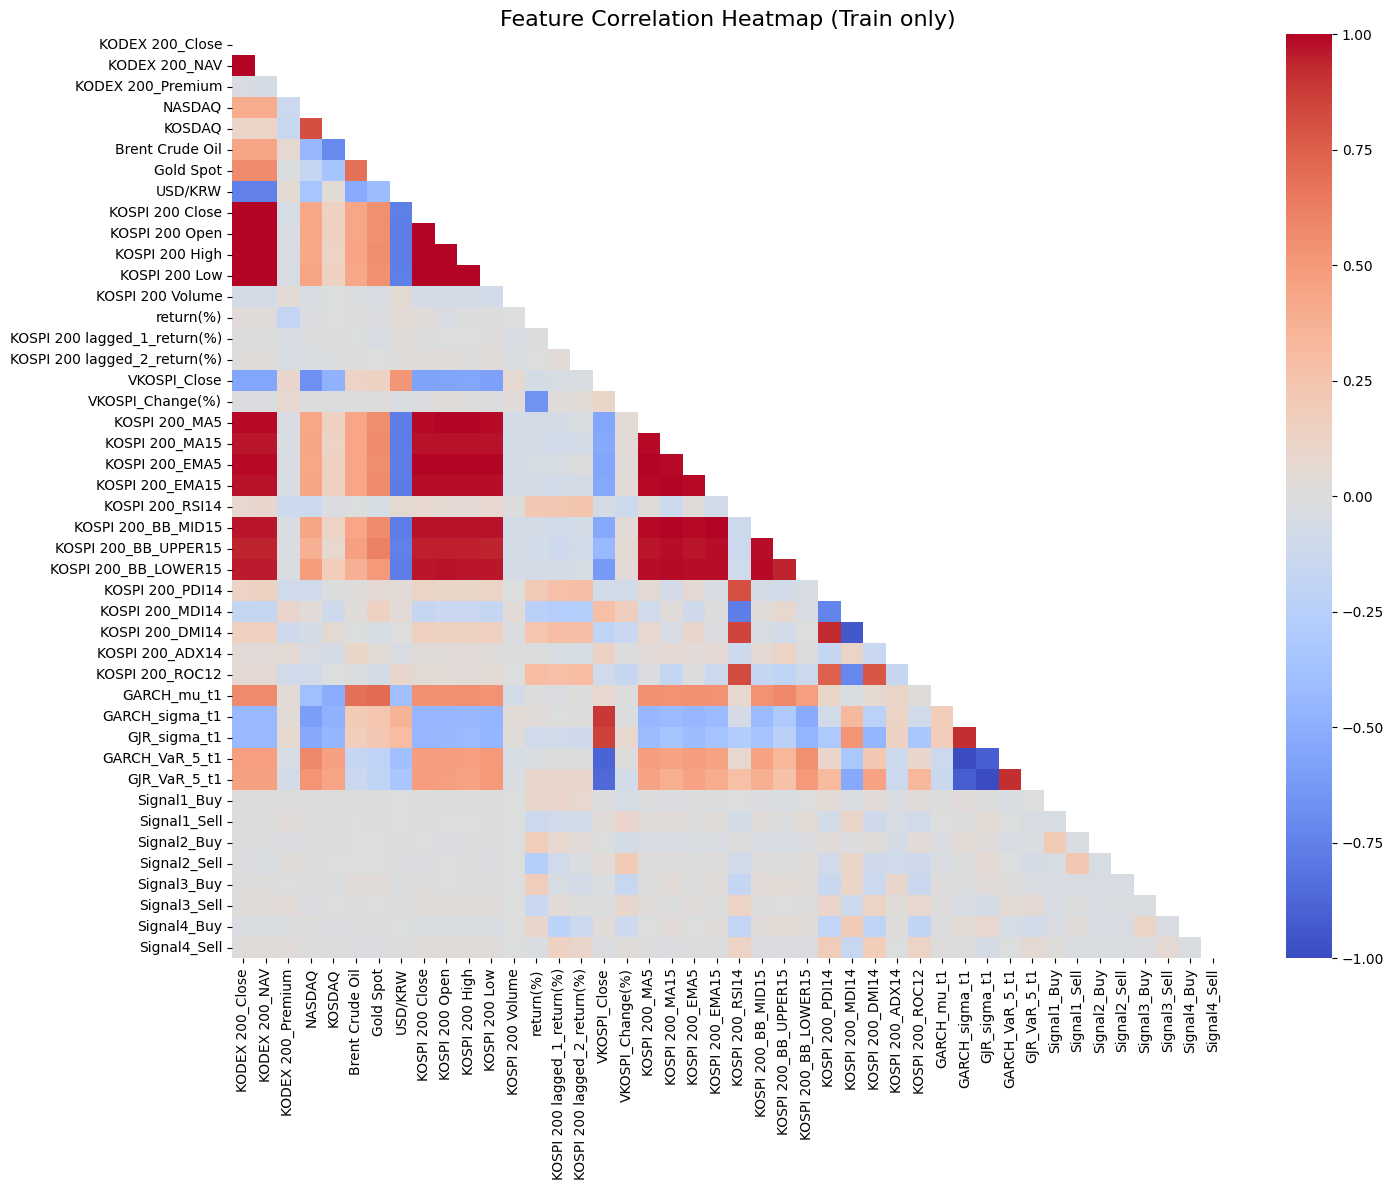


[ 📊 변수별 VIF 결과 ]


c:\Users\Owner\Desktop\KDISS\TS_RL_proj\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,KOSPI 200_DMI14,inf
1,KOSPI 200_MA15,4503599627370496.0000
2,KOSPI 200_BB_MID15,3002399751580330.5000
3,KOSPI 200_BB_LOWER15,321685687669321.1250
4,KOSPI 200_BB_UPPER15,160842843834660.5625
5,KOSPI 200_PDI14,126861961334380.1719
6,KOSPI 200_MDI14,62118615549937.8750
7,KODEX 200_NAV,232342.5003
8,KODEX 200_Close,231797.3620
9,GARCH_sigma_t1,75172.2417



🚨 VIF 10 이상인 위험 변수 목록:
['KOSPI 200_DMI14', 'KOSPI 200_MA15', 'KOSPI 200_BB_MID15', 'KOSPI 200_BB_LOWER15', 'KOSPI 200_BB_UPPER15', 'KOSPI 200_PDI14', 'KOSPI 200_MDI14', 'KODEX 200_NAV', 'KODEX 200_Close', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200_EMA5', 'KOSPI 200_MA5', 'KOSPI 200 Close', 'KOSPI 200_EMA15', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'GARCH_mu_t1', 'KODEX 200_Premium', 'NASDAQ', 'VKOSPI_Close', 'KOSPI 200_ROC12', 'return(%)']


In [35]:
check_multicollinearity(full_data, target_col='Risk_Label')

### 볼린저 밴드 폭(BBwidth) 변수 생성 및 VIF 확인

🚀 다중공선성(Multicollinearity) 분석 시작
   기준 데이터: train 기간만 사용
전체 입력 데이터 형태: (4108, 43)
VIF 계산에 사용한 train 데이터 형태: (1848, 43)

✅ 분석에 사용된 데이터 형태 (train 기준, 결측치 제외, 숫자형만): (1848, 42)



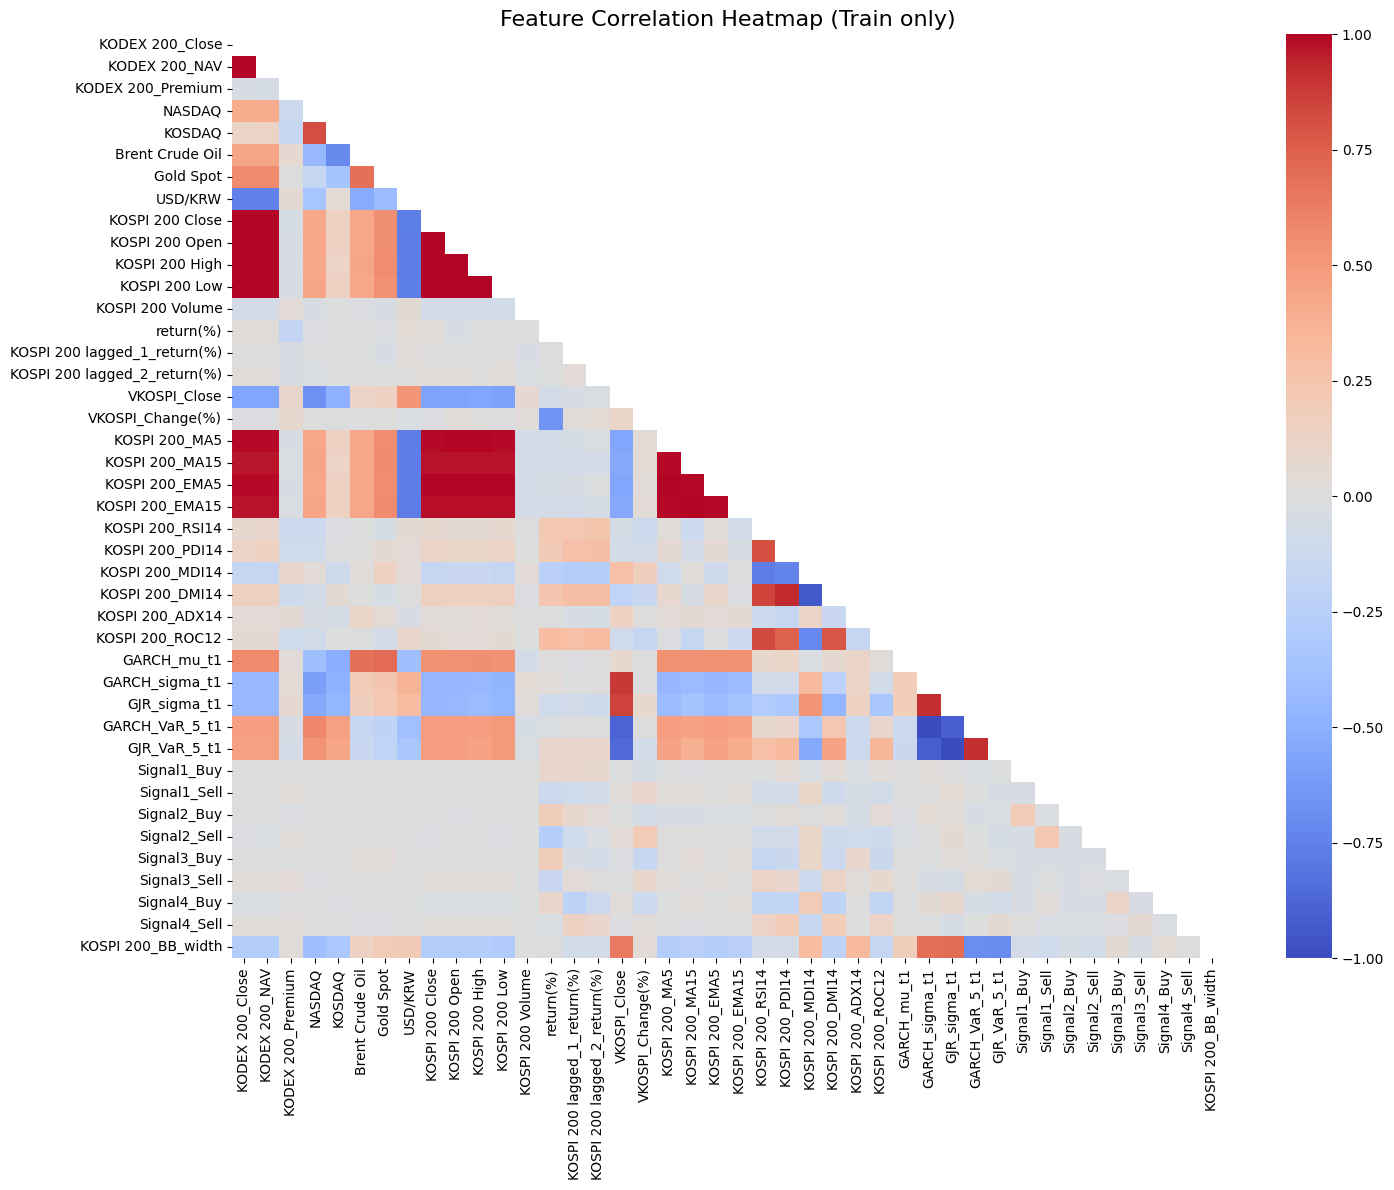


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KOSPI 200_MDI14,391617358901782.2500
1,KOSPI 200_DMI14,33608952443063.4023
2,KOSPI 200_PDI14,23456248059221.3320
3,KODEX 200_NAV,232225.7166
4,KODEX 200_Close,231684.6083
5,GARCH_sigma_t1,75182.8814
6,GARCH_VaR_5_t1,74473.9698
7,GJR_sigma_t1,33510.5792
8,GJR_VaR_5_t1,33430.4616
9,KOSPI 200_EMA5,24511.0623



🚨 VIF 10 이상인 위험 변수 목록:
['KOSPI 200_MDI14', 'KOSPI 200_DMI14', 'KOSPI 200_PDI14', 'KODEX 200_NAV', 'KODEX 200_Close', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200_EMA5', 'KOSPI 200_MA5', 'KOSPI 200 Close', 'KOSPI 200_EMA15', 'KOSPI 200_MA15', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'GARCH_mu_t1', 'KODEX 200_Premium', 'NASDAQ', 'VKOSPI_Close', 'KOSPI 200_ROC12', 'return(%)']


In [36]:
full_data_a = full_data.assign(
    **{'KOSPI 200_BB_width': 
       (full_data['KOSPI 200_BB_UPPER15'] - full_data['KOSPI 200_BB_LOWER15']) / full_data['KOSPI 200_BB_MID15']}).drop(columns=['KOSPI 200_BB_UPPER15','KOSPI 200_BB_LOWER15','KOSPI 200_BB_MID15'])

check_multicollinearity(full_data_a, target_col='Risk_Label')

## MDI, PDI 제거 후 VIF 확인 (DMI만 이용)

🚀 다중공선성(Multicollinearity) 분석 시작
   기준 데이터: train 기간만 사용
전체 입력 데이터 형태: (4108, 41)
VIF 계산에 사용한 train 데이터 형태: (1848, 41)

✅ 분석에 사용된 데이터 형태 (train 기준, 결측치 제외, 숫자형만): (1848, 40)



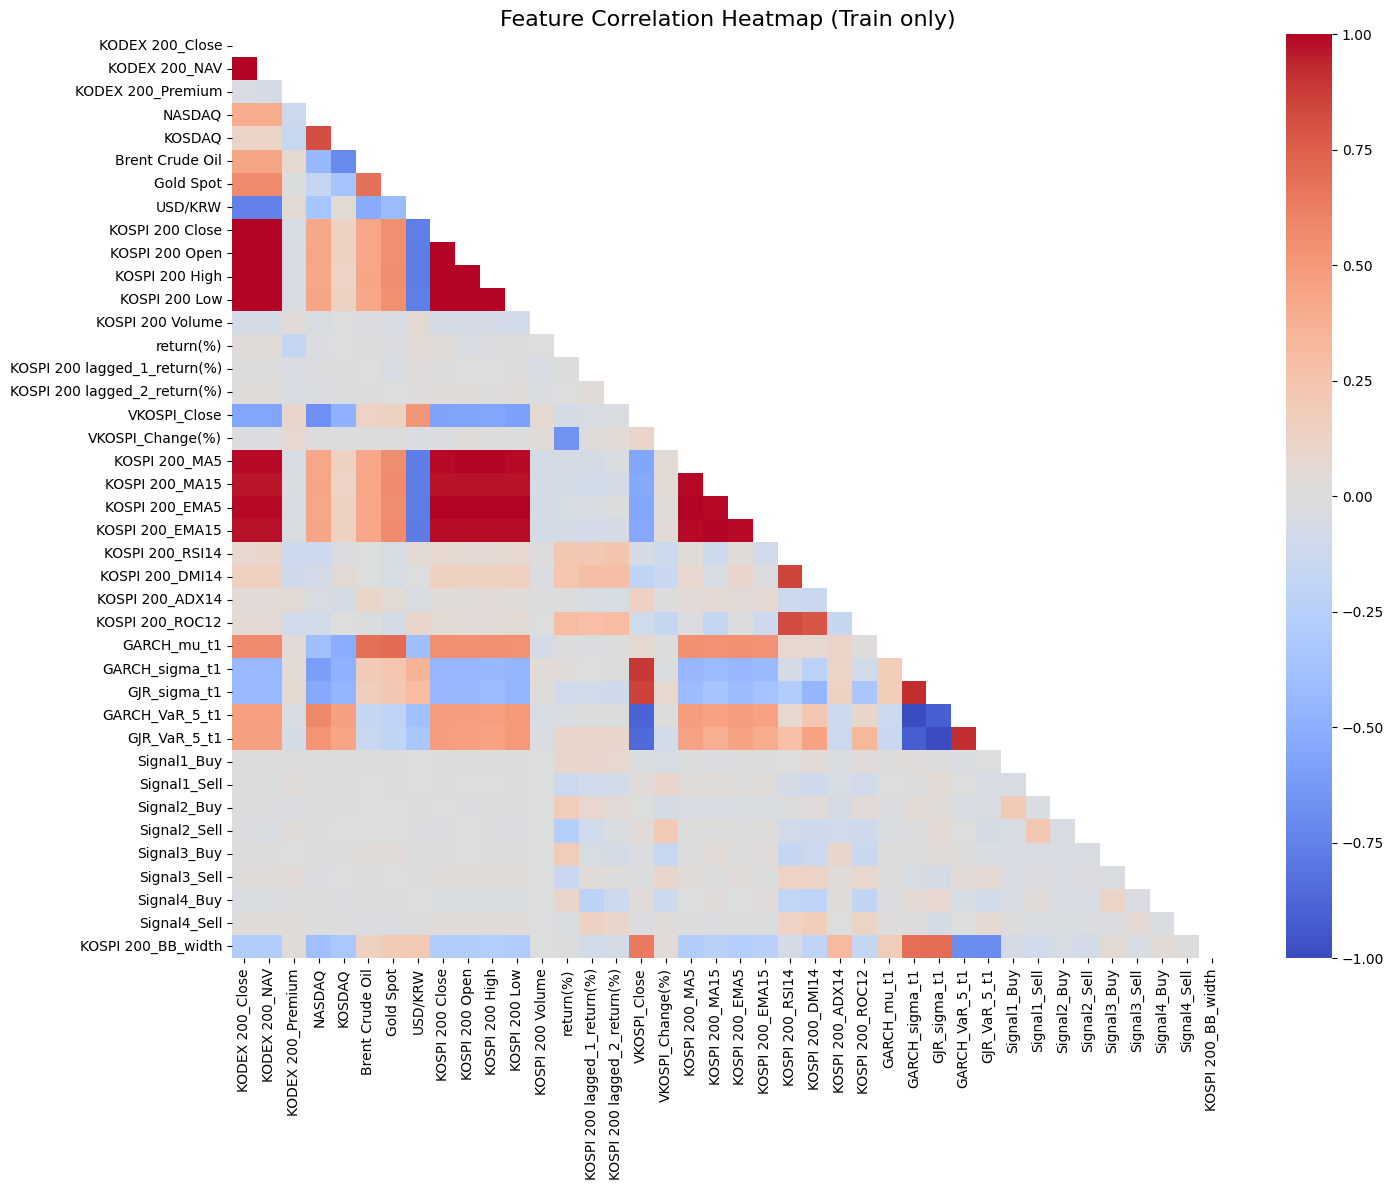


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_NAV,232175.0614
1,KODEX 200_Close,231649.8396
2,GARCH_sigma_t1,74684.2245
3,GARCH_VaR_5_t1,73984.4676
4,GJR_sigma_t1,33405.9520
5,GJR_VaR_5_t1,33320.2702
6,KOSPI 200_EMA5,24504.1448
7,KOSPI 200_MA5,6030.9058
8,KOSPI 200 Close,4250.5259
9,KOSPI 200_EMA15,2067.4151



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_NAV', 'KODEX 200_Close', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200_EMA5', 'KOSPI 200_MA5', 'KOSPI 200 Close', 'KOSPI 200_EMA15', 'KOSPI 200_MA15', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'GARCH_mu_t1', 'KODEX 200_Premium', 'VKOSPI_Close', 'NASDAQ', 'KOSPI 200_ROC12', 'return(%)']


In [37]:
# 1. full_data_a에서 MDI, PDI 제거 후 full_data_b에 대입
full_data_b = full_data_a.drop(columns=['KOSPI 200_MDI14', 'KOSPI 200_PDI14'], errors='ignore')

# 2. full_data_b로 VIF 함수 실행
check_multicollinearity(full_data_b, target_col='Risk_Label')

### EMA12/26 추가를 통한 PPO 계산, MA족 변수 모두 드랍 후 VIF 확인

KOSPI 200_PPO         0
KOSPI 200_PPO_Hist    0
dtype: int64
🚀 다중공선성(Multicollinearity) 분석 시작
   기준 데이터: train 기간만 사용
전체 입력 데이터 형태: (4108, 39)
VIF 계산에 사용한 train 데이터 형태: (1848, 39)

✅ 분석에 사용된 데이터 형태 (train 기준, 결측치 제외, 숫자형만): (1848, 38)



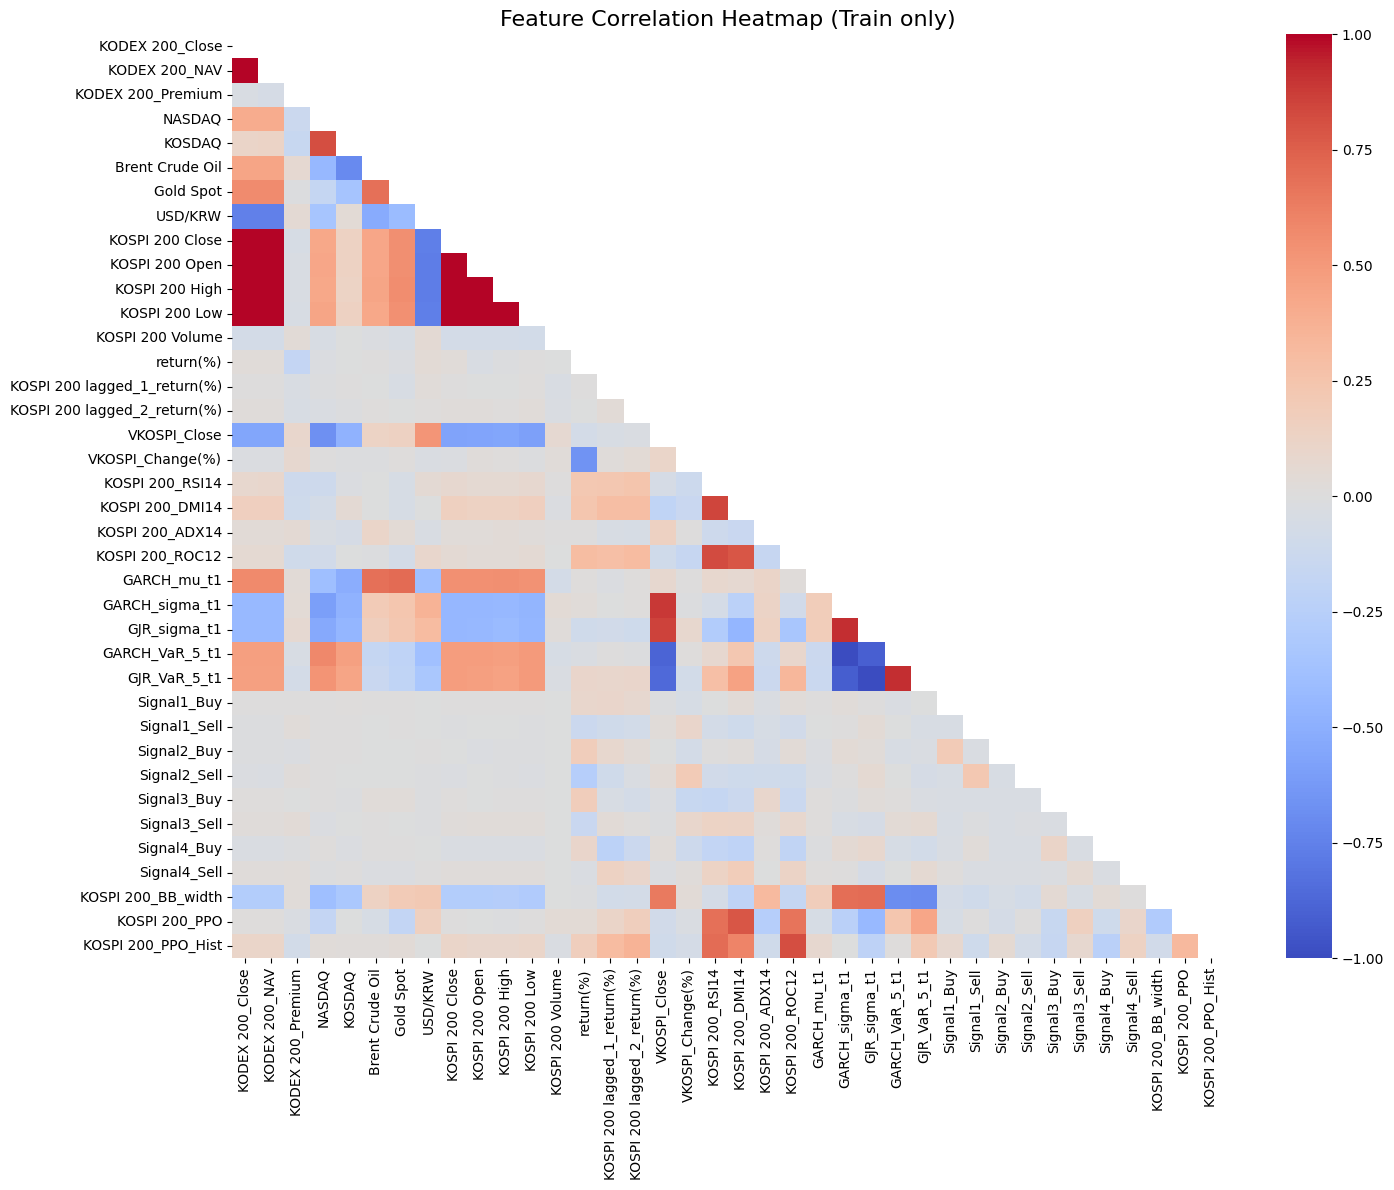


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_NAV,232187.8729
1,KODEX 200_Close,231687.7836
2,GARCH_sigma_t1,73631.9775
3,GARCH_VaR_5_t1,72981.5902
4,GJR_sigma_t1,33354.6676
5,GJR_VaR_5_t1,33313.2832
6,KOSPI 200 Close,1324.4481
7,KOSPI 200 High,1273.1848
8,KOSPI 200 Low,868.8793
9,KOSPI 200 Open,798.8642



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_NAV', 'KODEX 200_Close', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200 Close', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'GARCH_mu_t1', 'KODEX 200_Premium', 'NASDAQ', 'VKOSPI_Close']


In [38]:
data_2008_test = pd.read_csv(r'..\..\data\raw\data_2008.csv',
    index_col=0,
    parse_dates=True
).sort_index()

close = data_2008_test['KOSPI 200 Close']

ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()

# 1. PPO 계산 (PPO = (EMA12 - EMA26) / EMA26 * 100)
data_2008_test['KOSPI 200_PPO'] = (ema12 - ema26) / ema26 * 100

# 2. PPO 시그널 계산 (PPO의 9일 지수이동평균)
data_2008_test['KOSPI 200_PPO_Signal'] = (data_2008_test['KOSPI 200_PPO']
    .ewm(span=9, adjust=False).mean()
)

# 3. PPO 히스토그램 계산 (PPO - PPO 시그널)
data_2008_test['KOSPI 200_PPO_Hist'] = (data_2008_test['KOSPI 200_PPO']
    - data_2008_test['KOSPI 200_PPO_Signal']
)

# 4. full_data_b를 복사하여 full_data_c 생성 후 기존에 같은 컬럼이 있으면 제거
full_data_c = full_data_b.copy().sort_index()
full_data_c = full_data_c.drop(columns=[
    'KOSPI 200_PPO',
    'KOSPI 200_PPO_Hist'
], errors='ignore')

# 5. data_2008_test에서 필요한 컬럼(PPO, PPO_Hist)만 병합
full_data_c = full_data_c.join(
    data_2008_test[['KOSPI 200_PPO', 'KOSPI 200_PPO_Hist']],
    how='left'
)

# 6. 다중공선성의 원인이 되는 재료 변수들(이동 평균 족 변수) 일괄 삭제
full_data_c = full_data_c.drop(columns=[
    'KOSPI 200_MA5',
    'KOSPI 200_MA15',
    'KOSPI 200_EMA5',
    'KOSPI 200_EMA15'
], errors='ignore')

# 5.5 full_data_c의 변수별 결측치 확인
print(full_data_c[['KOSPI 200_PPO', 'KOSPI 200_PPO_Hist']].isna().sum())

# 6. 결과 확인 및 VIF 실행
check_multicollinearity(full_data_c, target_col='Risk_Label')

### VaR족 변수 제거

🚀 다중공선성(Multicollinearity) 분석 시작
   기준 데이터: train 기간만 사용
전체 입력 데이터 형태: (4108, 35)
VIF 계산에 사용한 train 데이터 형태: (1848, 35)

✅ 분석에 사용된 데이터 형태 (train 기준, 결측치 제외, 숫자형만): (1848, 34)



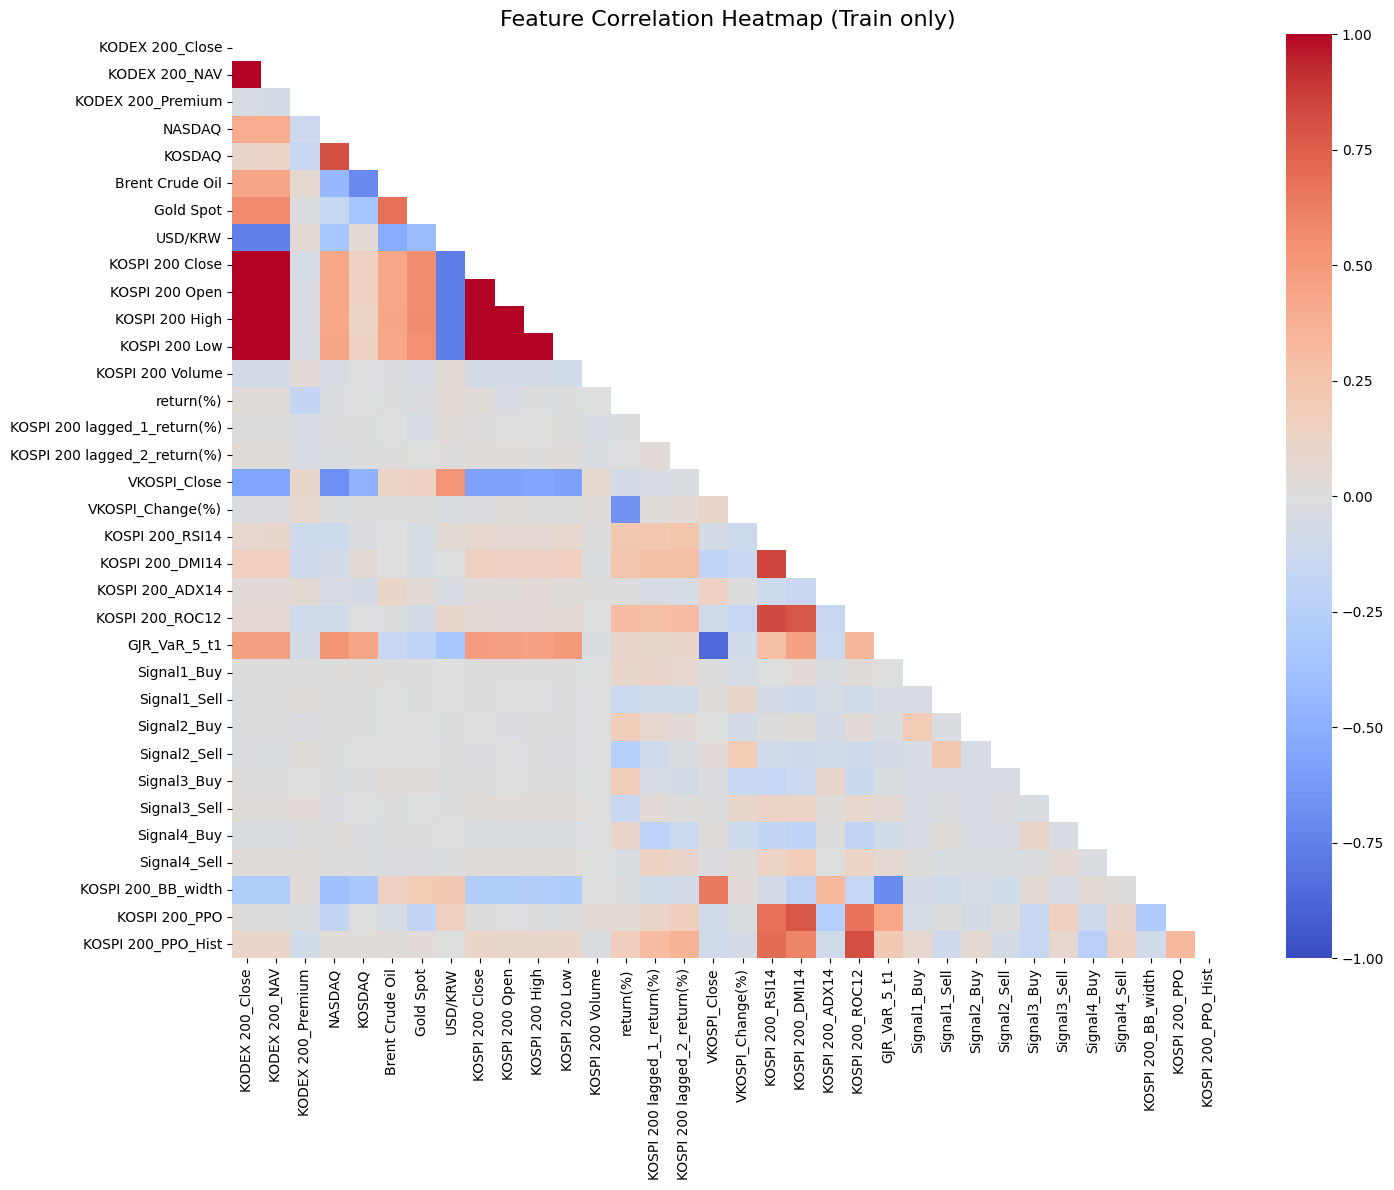


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_NAV,230523.8626
1,KODEX 200_Close,229717.1141
2,KOSPI 200 Close,1317.5820
3,KOSPI 200 High,1264.4348
4,KOSPI 200 Low,857.7495
5,KOSPI 200 Open,797.7086
6,KODEX 200_Premium,115.2090
7,GJR_VaR_5_t1,11.0198
8,VKOSPI_Close,10.8436
9,NASDAQ,9.2945



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_NAV', 'KODEX 200_Close', 'KOSPI 200 Close', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'KODEX 200_Premium', 'GJR_VaR_5_t1', 'VKOSPI_Close']


In [39]:
full_data_d = full_data_c.copy().sort_index()

full_data_d = full_data_d.drop(columns=[
    "GARCH_sigma_t1",
    "GJR_sigma_t1",
    "GARCH_mu_t1",
    "GARCH_VaR_5_t1"
], errors="ignore")

# GARCH_sigma_t1과 GARCH_VaR_5_t1은 선형 종속관계이며, 
# GJR_sigma_t1과 GARCH_mu_t1도 VIF가 높게 나와서 제거했다.
# GARCH_VaR_5_t1과 GJR_VaR_5_t1 중 더 중요한 GJR_VaR_5_t1은 남겨두었다.

# VIF 재확인
check_multicollinearity(full_data_d, target_col="Risk_Label")

### Open을 이용한 파생변수 Overnight Gap 생성 후, OHLC 제거

🚀 다중공선성(Multicollinearity) 분석 시작
   기준 데이터: train 기간만 사용
전체 입력 데이터 형태: (4108, 32)
VIF 계산에 사용한 train 데이터 형태: (1848, 32)

✅ 분석에 사용된 데이터 형태 (train 기준, 결측치 제외, 숫자형만): (1848, 31)



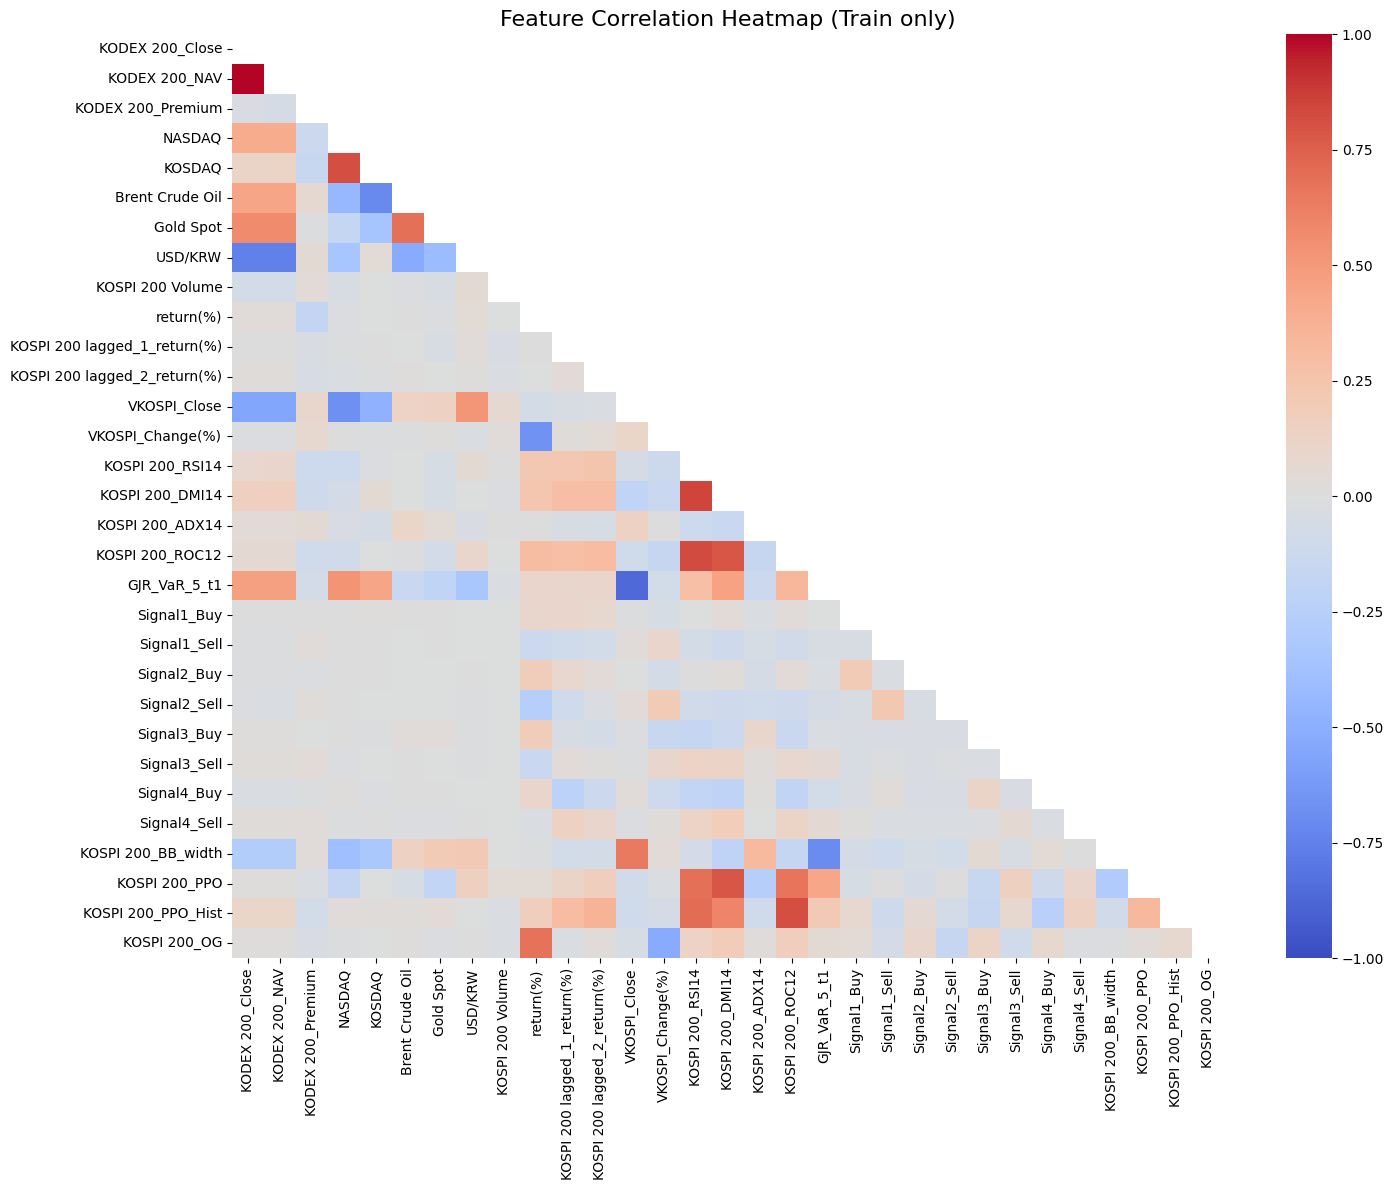


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_NAV,230919.7961
1,KODEX 200_Close,230356.3503
2,KODEX 200_Premium,115.4658
3,GJR_VaR_5_t1,10.5857
4,VKOSPI_Close,10.5374
5,KOSPI 200_ROC12,8.9101
6,NASDAQ,8.0595
7,KOSPI 200_DMI14,7.9381
8,KOSPI 200_PPO,7.5248
9,Brent Crude Oil,6.9157



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_NAV', 'KODEX 200_Close', 'KODEX 200_Premium', 'GJR_VaR_5_t1', 'VKOSPI_Close']


In [40]:
data_2008_test = pd.read_csv(
    r'..\..\data\raw\data_2008.csv',
    index_col=0,
    parse_dates=True
).sort_index()

full_data_e = full_data_d.copy().sort_index()

# 기존 OG 컬럼이 있으면 제거
full_data_e = full_data_e.drop(columns=['KOSPI 200_OG'], errors='ignore')

# 1. 전일 종가
prev_close = data_2008_test['KOSPI 200 Close'].shift(1)

# 2. Overnight Gap 계산
data_2008_test['KOSPI 200_OG'] = (
    (data_2008_test['KOSPI 200 Open'] - prev_close)
    / prev_close
) * 100

# 3. 날짜 인덱스 기준 병합
full_data_e = full_data_e.join(
    data_2008_test[['KOSPI 200_OG']],
    how='left'
)

# 4. full_data_e의 OHLC 컬럼 제거
full_data_e = full_data_e.drop(
    columns=['KOSPI 200 Open', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Close'])

# VIF 확인
check_multicollinearity(full_data_e, target_col="Risk_Label")

### NASDAQ / Gold Spot의 로그 수익률화 및 ROC12 제거

결측치 확인:
NASDAQ_return(%)       0
Gold Spot_return(%)    0
dtype: int64
row count: 4108 -> 4108
🚀 다중공선성(Multicollinearity) 분석 시작
   기준 데이터: train 기간만 사용
전체 입력 데이터 형태: (4108, 31)
VIF 계산에 사용한 train 데이터 형태: (1848, 31)

✅ 분석에 사용된 데이터 형태 (train 기준, 결측치 제외, 숫자형만): (1848, 30)



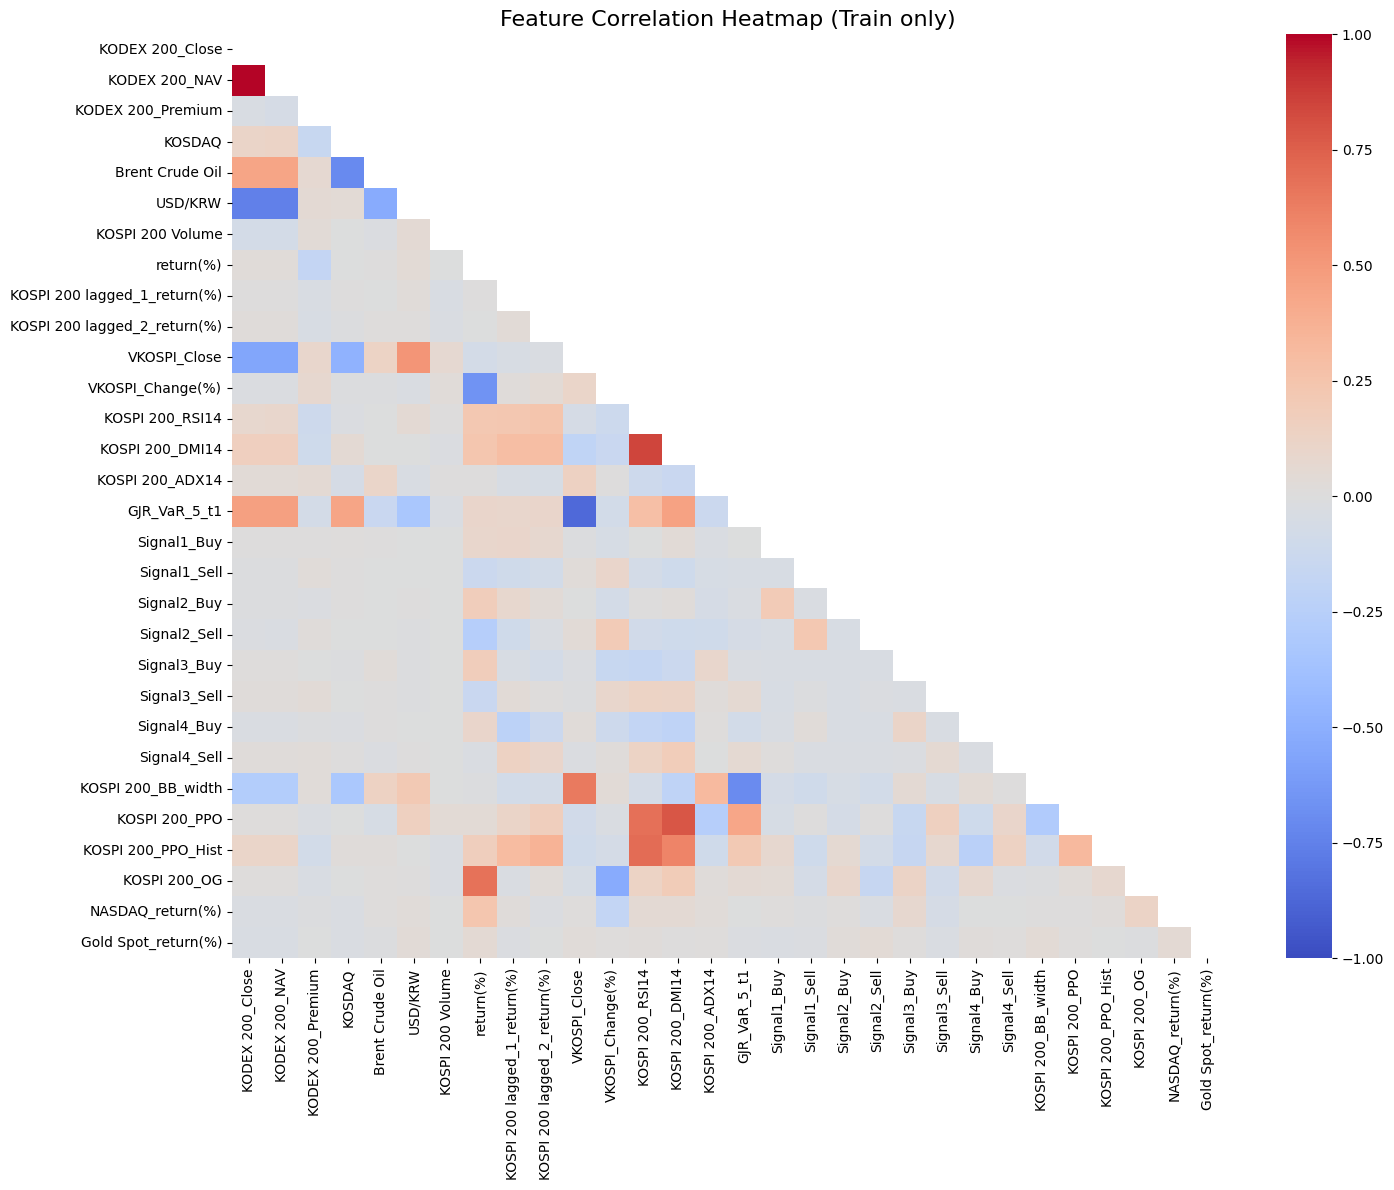


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_NAV,228605.8387
1,KODEX 200_Close,228113.4658
2,KODEX 200_Premium,114.3996
3,GJR_VaR_5_t1,10.3811
4,VKOSPI_Close,9.7866
5,KOSPI 200_DMI14,7.2650
6,Brent Crude Oil,5.7539
7,KOSPI 200_PPO,5.7497
8,KOSPI 200_RSI14,5.5520
9,KOSDAQ,4.1224



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_NAV', 'KODEX 200_Close', 'KODEX 200_Premium', 'GJR_VaR_5_t1']


In [41]:
# =========================
# 1. 2008년부터의 raw 데이터 불러오기
# =========================
data_2008_test = pd.read_csv(
    r'..\..\data\raw\data_2008.csv',
    index_col=0,
    parse_dates=True
).sort_index()

# =========================
# 2. NASDAQ, Gold Spot 변화율 생성
#    log(P_t / P_{t-1}) * 100
# =========================
data_2008_test["NASDAQ_return(%)"] = (
    np.log(data_2008_test["NASDAQ"] / data_2008_test["NASDAQ"].shift(1)) * 100
)
data_2008_test["Gold Spot_return(%)"] = (
    np.log(data_2008_test["Gold Spot"] / data_2008_test["Gold Spot"].shift(1)) * 100
)

# =========================
# 3. 현재 분석 데이터 복사
# =========================
full_data_f = full_data_e.copy().sort_index()

# =========================
# 4. 기존 return 컬럼이 있으면 제거
# =========================
full_data_f = full_data_f.drop(columns=[
    "NASDAQ_return(%)",
    "Gold Spot_return(%)",
    "KOSPI 200_ROC12"
], errors="ignore")

# =========================
# 5. 날짜 인덱스 기준으로 변화율 변수 병합
# =========================
full_data_f = full_data_f.join(
    data_2008_test[["NASDAQ_return(%)", "Gold Spot_return(%)"]],
    how="left"
)

# =========================
# 6. 원 변수 제거
# =========================
full_data_f = full_data_f.drop(columns=[
    "NASDAQ",
    "Gold Spot"
], errors="ignore")

# =========================
# 7. 병합 결과 확인
# =========================
print("결측치 확인:")
print(full_data_f[["NASDAQ_return(%)", "Gold Spot_return(%)"]].isna().sum())
print("row count:", len(full_data_e), "->", len(full_data_f))

# =========================
# 8. VIF 확인
# =========================
check_multicollinearity(full_data_f, target_col="Risk_Label")

### KOSDAQ / Brent Crude Oil / USD/KRW도 수익률 및 변화량으로 변환

🚀 다중공선성(Multicollinearity) 분석 시작
   기준 데이터: train 기간만 사용
전체 입력 데이터 형태: (4108, 31)
VIF 계산에 사용한 train 데이터 형태: (1848, 31)

✅ 분석에 사용된 데이터 형태 (train 기준, 결측치 제외, 숫자형만): (1848, 30)



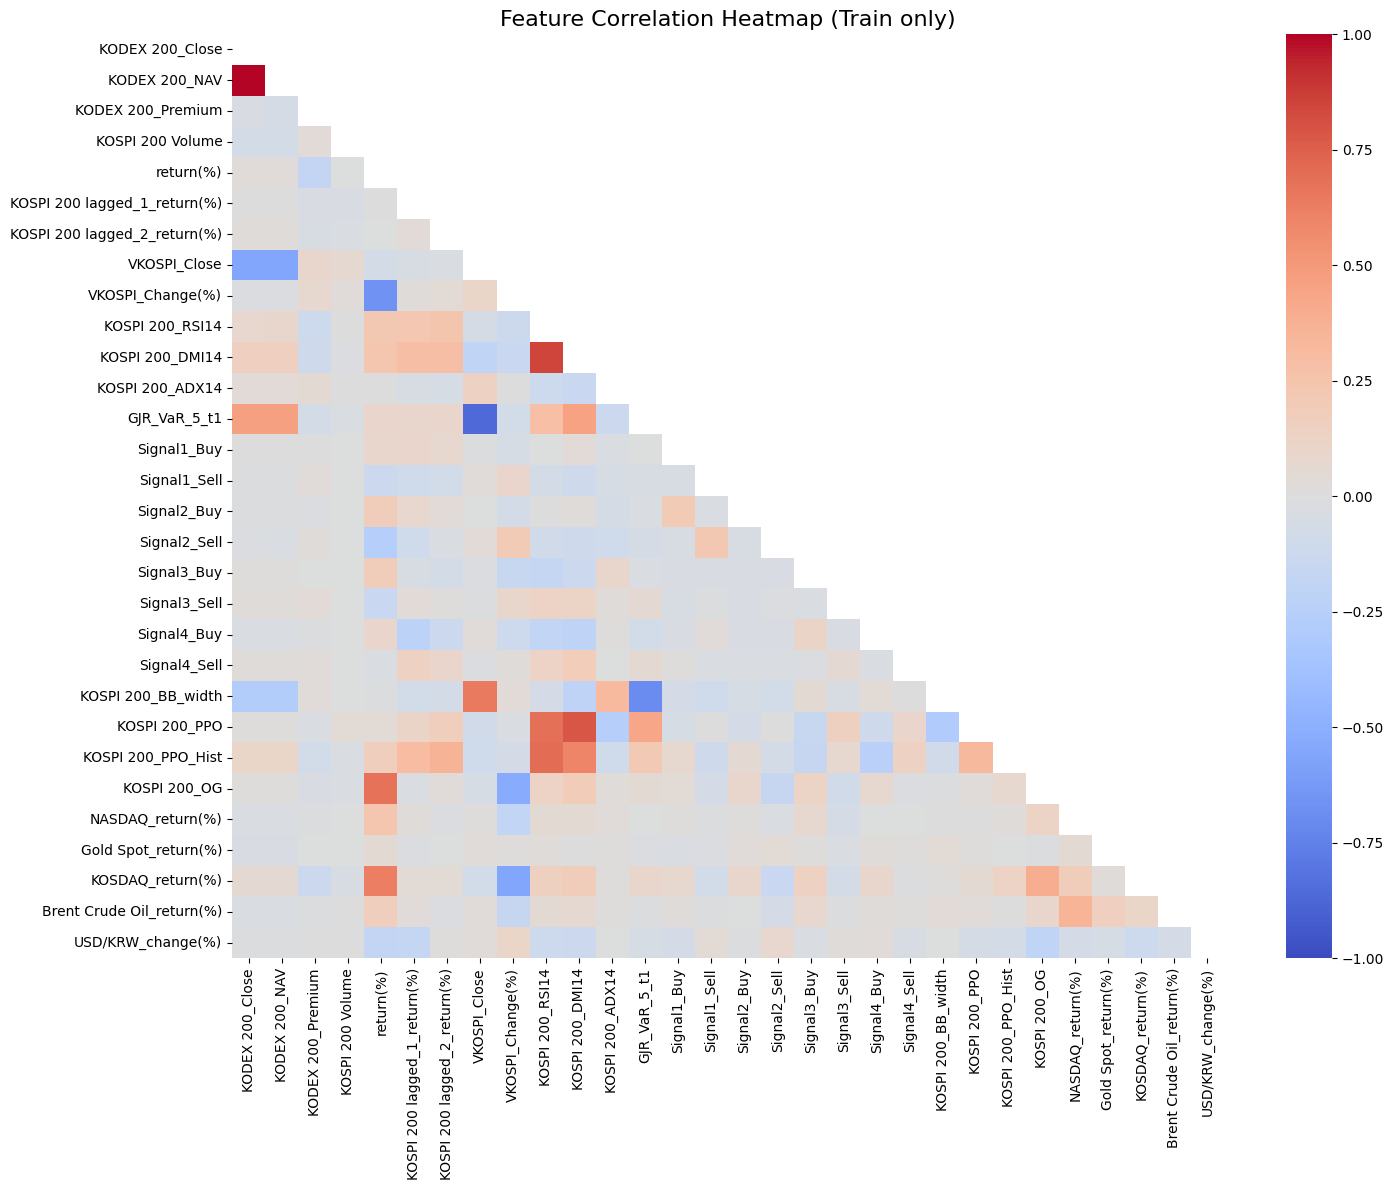


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_NAV,229127.2584
1,KODEX 200_Close,228644.8576
2,KODEX 200_Premium,114.7855
3,GJR_VaR_5_t1,9.9618
4,VKOSPI_Close,8.2038
5,KOSPI 200_DMI14,7.2180
6,KOSPI 200_PPO,5.5945
7,KOSPI 200_RSI14,5.4439
8,return(%),3.4894
9,KOSPI 200_PPO_Hist,2.6326



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_NAV', 'KODEX 200_Close', 'KODEX 200_Premium']


In [42]:
# =========================
# 1. 2008년부터의 raw 데이터 불러오기
# =========================
data_2008_test = pd.read_csv(
    r'..\..\data\raw\data_2008.csv',
    index_col=0,
    parse_dates=True
).sort_index()

# =========================
# 2. KOSDAQ / Brent Crude Oil / USD/KRW 변환
#    KODEX 200, KOSDAQ, Brent: 로그수익률
#    USD/KRW: 로그변화율
# =========================
data_2008_test["KOSDAQ_return(%)"] = (
    np.log(data_2008_test["KOSDAQ"] / data_2008_test["KOSDAQ"].shift(1)) * 100
)

data_2008_test["Brent Crude Oil_return(%)"] = (
    np.log(data_2008_test["Brent Crude Oil"] / data_2008_test["Brent Crude Oil"].shift(1)) * 100
)

data_2008_test["USD/KRW_change(%)"] = (
    np.log(data_2008_test["USD/KRW"] / data_2008_test["USD/KRW"].shift(1)) * 100
)

# =========================
# 3. 현재 분석 데이터 복사
# =========================
full_data_g = full_data_f.copy().sort_index()

# =========================
# 4. 기존 변환 컬럼이 있으면 제거
# =========================
new_cols = [
    "KOSDAQ_return(%)",
    "Brent Crude Oil_return(%)",
    "USD/KRW_change(%)"
]

full_data_g = full_data_g.drop(columns=new_cols, errors="ignore")

# =========================
# 5. 날짜 인덱스 기준으로 변환 변수 병합
# =========================
full_data_g = full_data_g.join(
    data_2008_test[new_cols],
    how="left"
)

# =========================
# 6. 원레벨 변수 제거
# =========================
full_data_g = full_data_g.drop(columns=[
    "KOSDAQ",
    "Brent Crude Oil",
    "USD/KRW"
], errors="ignore")

# =========================
# 7. VIF 확인
# =========================
check_multicollinearity(full_data_g, target_col="Risk_Label")

### KODEX 200_Premium(괴리율)만 남기기

🚀 다중공선성(Multicollinearity) 분석 시작
   기준 데이터: train 기간만 사용
전체 입력 데이터 형태: (4108, 29)
VIF 계산에 사용한 train 데이터 형태: (1848, 29)

✅ 분석에 사용된 데이터 형태 (train 기준, 결측치 제외, 숫자형만): (1848, 28)



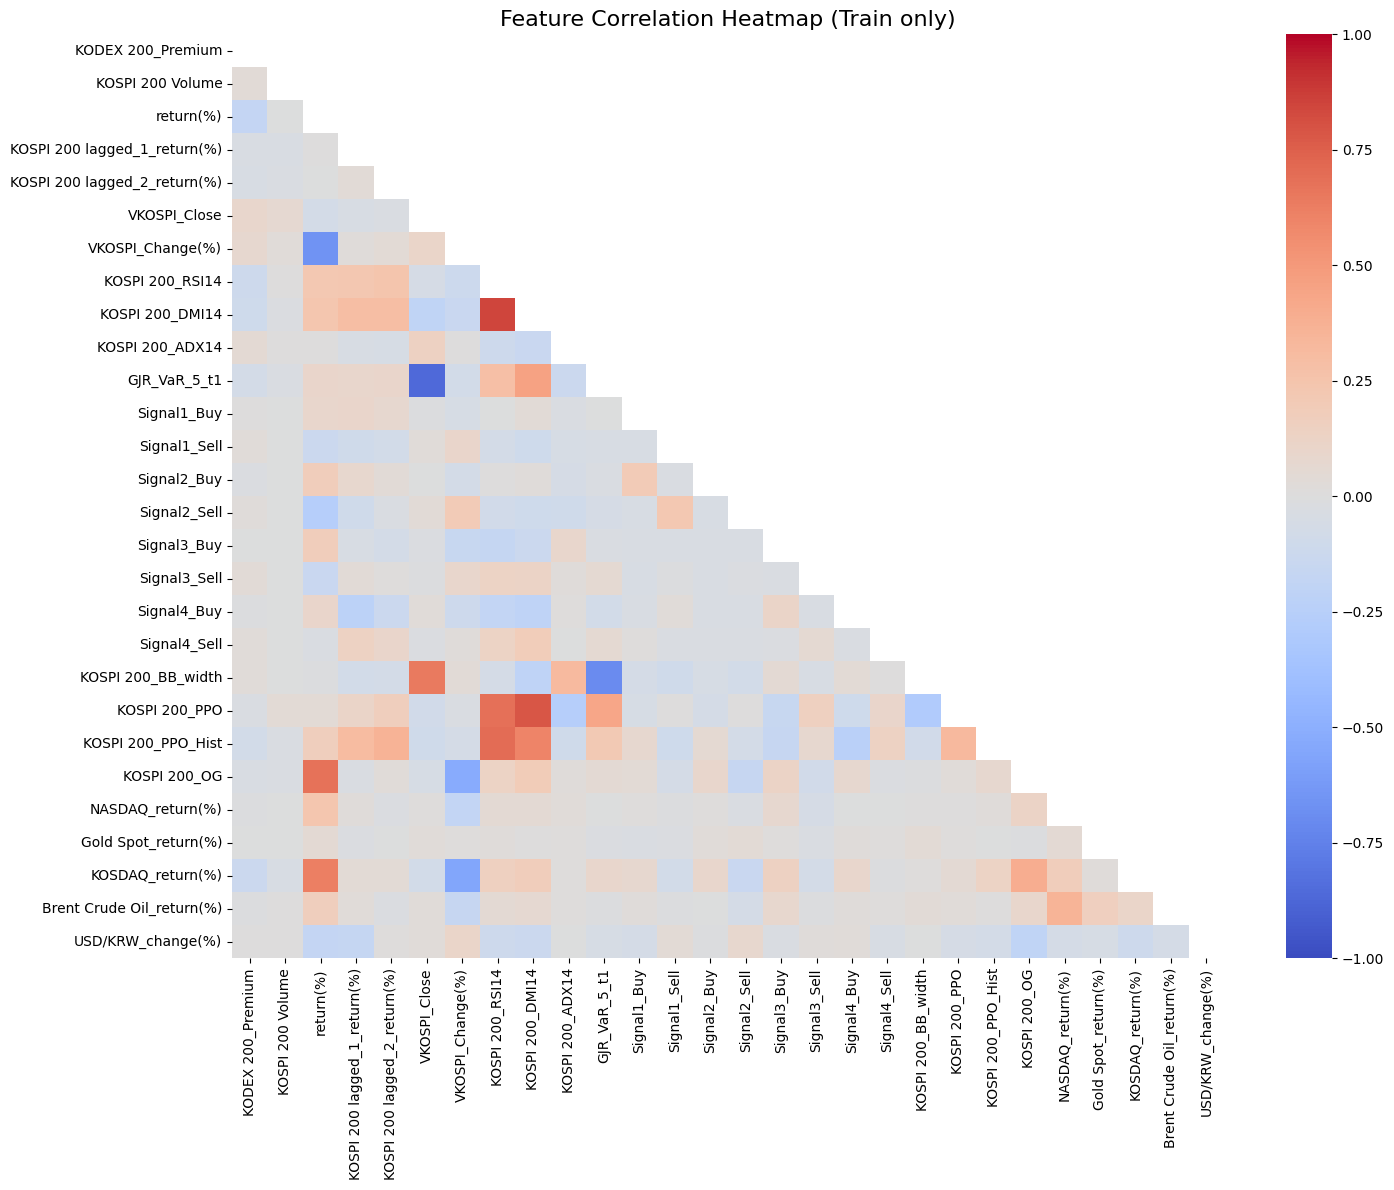


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,GJR_VaR_5_t1,9.9604
1,VKOSPI_Close,7.6335
2,KOSPI 200_DMI14,7.1040
3,KOSPI 200_PPO,5.5334
4,KOSPI 200_RSI14,5.4412
5,return(%),3.4714
6,KOSPI 200_PPO_Hist,2.6259
7,KOSPI 200_BB_width,2.6081
8,VKOSPI_Change(%),2.0337
9,KOSPI 200_OG,2.0180



🚨 VIF 10 이상인 위험 변수 목록:
없음


In [43]:
# =========================
# 1. 현재 분석 데이터 복사
# =========================
full_data_h = full_data_g.copy().sort_index()

# =========================
# 2. KODEX의 종가(Close) 및 순자산가치(NAV) 변수 제거
# =========================
full_data_h = full_data_h.drop(columns=[
    "KODEX 200_Close",
    "KODEX 200_NAV"
], errors="ignore")

# =========================
# 3. VIF 확인
# =========================
check_multicollinearity(full_data_h, target_col="Risk_Label")

### 변수 재정렬

In [44]:
new_order = [
    'KODEX 200_Premium','KOSDAQ_return(%)','NASDAQ_return(%)','Brent Crude Oil_return(%)',
    'Gold Spot_return(%)','USD/KRW_change(%)',

    'KOSPI 200 Volume',

    'return(%)',
    'KOSPI 200 lagged_1_return(%)',
    'KOSPI 200 lagged_2_return(%)',

    'VKOSPI_Close',
    'VKOSPI_Change(%)',

    'KOSPI 200_RSI14',
    'KOSPI 200_DMI14',
    'KOSPI 200_ADX14',
    'KOSPI 200_BB_width',
    'KOSPI 200_PPO',
    'KOSPI 200_PPO_Hist',
    'KOSPI 200_OG',

    'GJR_VaR_5_t1',

    'Signal1_Buy',
    'Signal1_Sell',
    'Signal2_Buy',
    'Signal2_Sell',
    'Signal3_Buy',
    'Signal3_Sell',
    'Signal4_Buy',
    'Signal4_Sell',

    'Risk_Label'
]

# 혹시 누락/오타 체크
missing_cols = [col for col in new_order if col not in full_data_h.columns]
extra_cols = [col for col in full_data_h.columns if col not in new_order]

print("누락된 컬럼:", missing_cols)
print("추가 컬럼:", extra_cols)

# =====================
# 최종 data_vif 생성
# =====================
data_vif = full_data_h[new_order].copy()

# data_vif.csv 저장: 오른쪽 코드(03-2. data_vif.ipynb)와 동일
data_vif.to_csv("../../data/processed/data_vif.csv", index=True)

# ============================================================
# train 기준으로 VIF를 판단하되,
# 이후 모델링에서 valid/test도 같은 파생변수 구조를 쓰도록 최종 데이터 분할 저장
# ============================================================
data_vif_train, data_vif_valid, data_vif_test = split_train_valid_test(data_vif)

data_vif_split = pd.concat(
    [data_vif_train, data_vif_valid, data_vif_test],
    axis=0
)

data_vif_split.to_csv("../../data/processed/data_vif.csv", index=True)


누락된 컬럼: []
추가 컬럼: []
